✅ Device: cpu
✅ Train images: 123167
✅ Val images  : 30793


Epoch 1/10: 100%|██████████| 3849/3849 [17:59<00:00,  3.57it/s, loss=0.0649, acc=0.9003]



✅ Epoch [1/10] Train Loss: 0.2463 | Train Acc: 0.9003 | Val Acc: 0.9523
✅ Best model saved


Epoch 2/10: 100%|██████████| 3849/3849 [09:13<00:00,  6.96it/s, loss=0.2143, acc=0.9568]



✅ Epoch [2/10] Train Loss: 0.1230 | Train Acc: 0.9568 | Val Acc: 0.9619
✅ Best model saved


...


✅ Epoch [8/10] Train Loss: 0.0555 | Train Acc: 0.9839 | Val Acc: 0.9875
✅ Best model saved


Epoch 9/10: 100%|██████████| 3849/3849 [07:45<00:00,  8.27it/s, loss=0.0394, acc=0.9844]



✅ Epoch [9/10] Train Loss: 0.0529 | Train Acc: 0.9844 | Val Acc: 0.9880
✅ Best model saved


Epoch 10/10: 100%|██████████| 3849/3849 [09:19<00:00,  6.87it/s, loss=0.0729, acc=0.9851]



✅ Epoch [10/10] Train Loss: 0.0508 | Train Acc: 0.9851 | Val Acc: 0.9881
✅ Best model saved

===== FINAL RESULTS =====
Accuracy : 0.988081706881434
Precision: 0.9900281961350663
Recall   : 0.9848132439458203
F1 Score : 0.9874138344936383


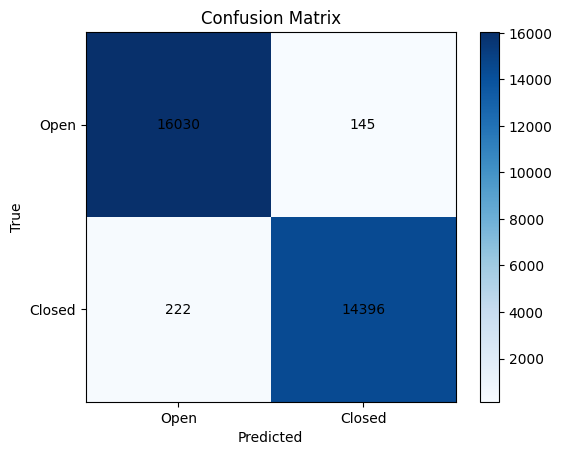

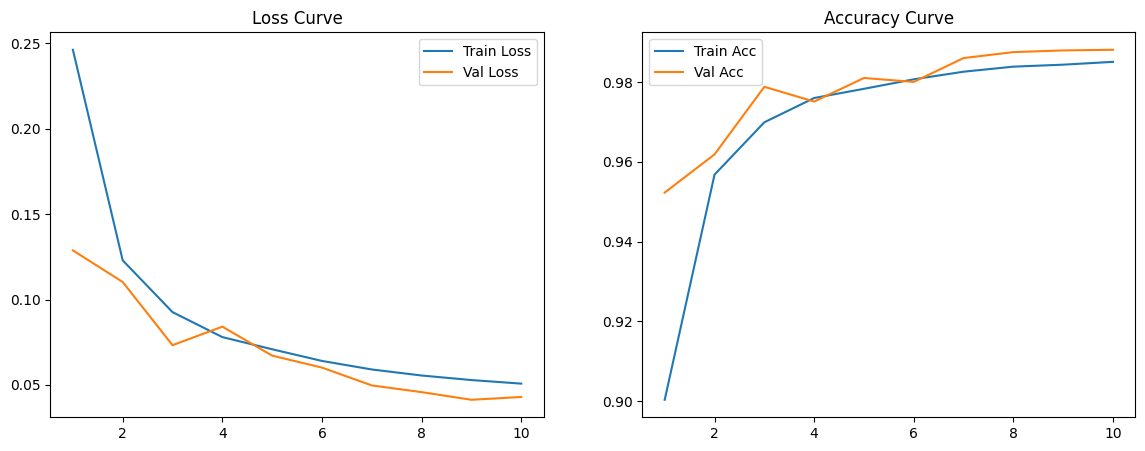

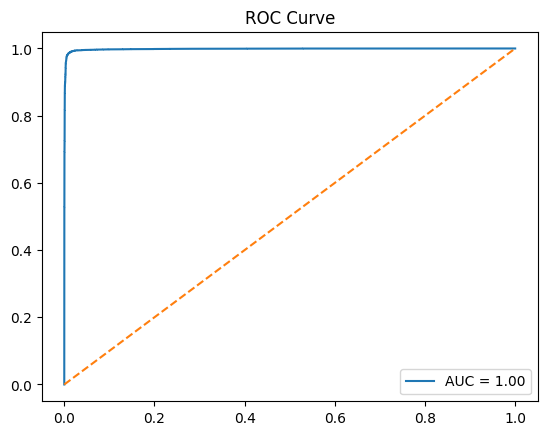

✅ Training complete
✅ Best model saved at: best_eye_cnn.pth


In [13]:
# =========================
# IMPORTS
# =========================
import os
import cv2
import dlib
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_curve, auc, accuracy_score
)
from scipy.spatial import distance as dist
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Device:", device)

# =========================
# DATASET
# =========================
class EyeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.images = []
        self.labels = []
        self.transform = transform

        for label, cls in enumerate(["open", "closed"]):
            cls_dir = os.path.join(root_dir, cls)
            for img in os.listdir(cls_dir):
                if img.lower().endswith((".jpg", ".png", ".jpeg")):
                    self.images.append(os.path.join(cls_dir, img))
                    self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = cv2.imread(self.images[idx], cv2.IMREAD_GRAYSCALE)
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# =========================
# CNN MODEL
# =========================
class EyeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 2)
        )

    def forward(self, x):
        return self.net(x)

# =========================
# TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# =========================
# EAR SETUP
# =========================
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(
  "/kaggle/input/datasets/humashasaba/shape-predictor-68-face-landmarks-dat/shape_predictor_68_face_landmarks.dat"
)

def eye_aspect_ratio(eye):
    A = dist.euclidean(eye[1], eye[5])
    B = dist.euclidean(eye[2], eye[4])
    C = dist.euclidean(eye[0], eye[3])
    return (A + B) / (2.0 * C)

def compute_ear(img_tensor):
    img = img_tensor.squeeze().cpu().numpy()
    img = ((img * 0.5) + 0.5) * 255
    img = img.astype("uint8")
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    rects = detector(img, 1)
    if len(rects) > 0:
        shape = predictor(img, rects[0])
        pts = np.array([[p.x, p.y] for p in shape.parts()])
        left = eye_aspect_ratio(pts[36:42])
        right = eye_aspect_ratio(pts[42:48])
        return (left + right) / 2.0
    return None

LOW_EAR = 0.20
HIGH_EAR = 0.30

# =========================
# DATA LOADERS
# =========================
BASE_PATH = "/kaggle/input/datasets/humashasaba/image1/Split"

train_dataset = EyeDataset(os.path.join(BASE_PATH, "train"), train_transform)
val_dataset   = EyeDataset(os.path.join(BASE_PATH, "val"), val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("✅ Train images:", len(train_dataset))
print("✅ Val images  :", len(val_dataset))

# =========================
# TRAINING SETUP
# =========================
model = EyeCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 10
best_val_acc = 0.0
model_path = "best_eye_cnn.pth"

train_losses, val_losses = [], []
train_accs, val_accs = [], []

# =========================
# TRAINING LOOP (REAL‑TIME)
# =========================
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0, 0, 0

    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for imgs, labels in progress:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # ✅ LIVE UPDATE
        progress.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{correct/total:.4f}"
        })

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # ---------- VALIDATION ----------
    model.eval()
    running_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / len(val_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"\n✅ Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), model_path)
        print("✅ Best model saved")

# =========================
# HYBRID TEST (CNN + EAR)
# =========================
all_true, all_pred, all_probs = [], [], []

model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        for i in range(len(imgs)):
            ear = compute_ear(imgs[i])
            final_pred = preds[i]

            if ear is not None:
                if ear < LOW_EAR:
                    final_pred = 1
                elif ear > HIGH_EAR:
                    final_pred = 0

            all_true.append(labels[i].item())
            all_pred.append(final_pred)
            all_probs.append(probs[i][1].item())

# =========================
# METRICS
# =========================
print("\n===== FINAL RESULTS =====")
print("Accuracy :", accuracy_score(all_true, all_pred))
print("Precision:", precision_score(all_true, all_pred))
print("Recall   :", recall_score(all_true, all_pred))
print("F1 Score :", f1_score(all_true, all_pred))

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(all_true, all_pred)
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Open", "Closed"])
plt.yticks([0, 1], ["Open", "Closed"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# =========================
# LOSS & ACC CURVES
# =========================
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="Train Acc")
plt.plot(epochs, val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

# =========================
# ROC CURVE
# =========================
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], "--")
plt.legend()
plt.title("ROC Curve")
plt.show()

print("✅ Training complete")
print("✅ Best model saved at:", model_path)